# GAN 2D Grid Pattern Synthesizer

Generative Adversarial Networks (GANs) utilize a two-player zero-sum game framework:
- **Generator ($G$):** Tries to synthesize realistic samples from random noise to fool the discriminator.
- **Discriminator ($D$):** Tries to distinguish between real dataset samples and generated fake samples.
This notebook implements a vanilla GAN in PyTorch to synthesize 2D coordinates forming a ring/circle shape, and visualizes the generated patterns in Matplotlib.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generate real data coordinates (600 samples forming a clean circle ring)
np.random.seed(235)
n_samples = 600
theta = np.random.uniform(0, 2*np.pi, n_samples)
X_real = np.column_stack((np.cos(theta), np.sin(theta))) + np.random.normal(0, 0.05, (n_samples, 2))

X_tensor = torch.FloatTensor(X_real) # Shape [600, 2]
print("Real Coordinate Dataset Shape:", X_tensor.shape)



Real Coordinate Dataset Shape: torch.Size([600, 2])


## GAN Generator & Discriminator Network Definitions

We build networks containing 3 dense layers each:
- **Generator**: Projects 2D latent noise vectors up to 2D coordinate spaces.
- **Discriminator**: Decodes 2D coordinates to single probability scores (real vs. fake).



In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=2, output_dim=2):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, output_dim)
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim=2):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

net_g = Generator()
net_d = Discriminator()

criterion = nn.BCELoss()
optimizer_g = optim.Adam(net_g.parameters(), lr=0.005)
optimizer_d = optim.Adam(net_d.parameters(), lr=0.005)



## Adversarial Training Loop

We train the GAN for 80 epochs. At each epoch, we optimize both the discriminator loss (classifying real/fake) and the generator loss.



In [3]:
epochs = 80
batch_size = 64
d_losses = []
g_losses = []

for epoch in range(1, epochs + 1):
    # Mini-batch loop
    permutation = torch.randperm(X_tensor.size(0))
    for i in range(0, X_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        real_batch = X_tensor[indices]
        curr_batch_size = real_batch.size(0)
        
        # Ground truth labels
        real_labels = torch.ones(curr_batch_size)
        fake_labels = torch.zeros(curr_batch_size)
        
        # ---------------------
        # Train Discriminator
        # ---------------------
        # 1. Real loss
        outputs_real = net_d(real_batch)
        d_loss_real = criterion(outputs_real, real_labels)
        
        # 2. Fake loss
        z = torch.randn(curr_batch_size, 2)
        fake_batch = net_g(z)
        outputs_fake = net_d(fake_batch.detach())
        d_loss_fake = criterion(outputs_fake, fake_labels)
        
        d_loss = d_loss_real + d_loss_fake
        optimizer_d.zero_grad()
        d_loss.backward()
        optimizer_d.step()
        
        # -----------------
        # Train Generator
        # -----------------
        outputs_fake_g = net_d(fake_batch)
        g_loss = criterion(outputs_fake_g, real_labels) # Tries to make D label fake as real (1)
        
        optimizer_g.zero_grad()
        g_loss.backward()
        optimizer_g.step()
        
    d_losses.append(d_loss.item())
    g_losses.append(g_loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:2d}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")



Epoch 20/80 | D Loss: 1.4010 | G Loss: 0.6133
Epoch 40/80 | D Loss: 1.5758 | G Loss: 0.6767
Epoch 60/80 | D Loss: 1.4070 | G Loss: 0.7994
Epoch 80/80 | D Loss: 1.3912 | G Loss: 0.7383


## Generated Ring Coordinate Patterns Visualization

We evaluate coordinates generated by the trained generator vs. the actual target real circles.



<cell>:16: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



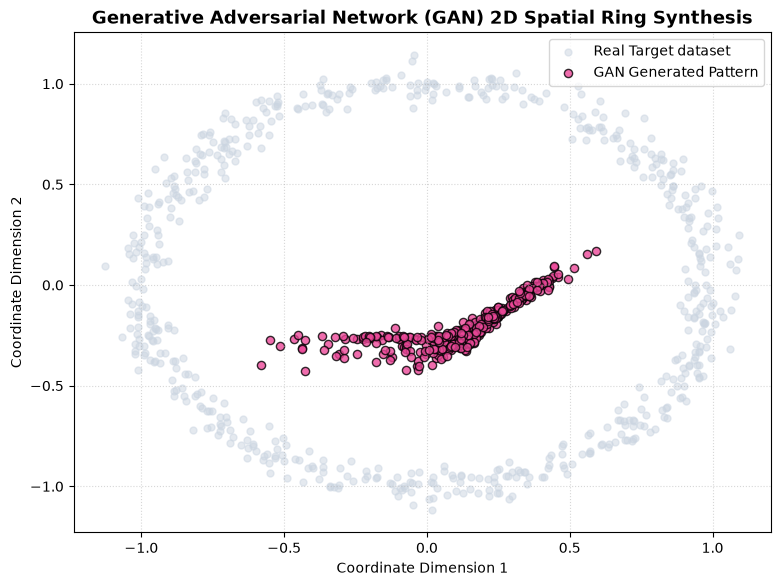

In [4]:
net_g.eval()
with torch.no_grad():
    z = torch.randn(400, 2)
    fake_data = net_g(z).numpy()

plt.figure(figsize=(9, 6.5))

plt.scatter(X_real[:, 0], X_real[:, 1], c='#CBD5E1', s=25, alpha=0.5, label='Real Target dataset')
plt.scatter(fake_data[:, 0], fake_data[:, 1], c='#EC4899', s=35, edgecolors='k', alpha=0.8, label='GAN Generated Pattern')

plt.title('Generative Adversarial Network (GAN) 2D Spatial Ring Synthesis', fontsize=13, fontweight='bold')
plt.xlabel('Coordinate Dimension 1')
plt.ylabel('Coordinate Dimension 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
